# Предоценочная диагностика DiD

## Назначение

событийная модель DiD по CORE-типам изменений для конверсионных метрик; проверка пред-трендов и раздельная интерпретация по `change_type`.

## Входные данные

Подготовленные выборки через `build_did_samples`; флаги `sch_flg`, `success_flg`, `utlz_flg`.

## Результаты

Таблицы pretrend-тестов, средних постэффектов и событийная модель графики.

## Статус

Диагностический ноутбук, входит в пайплайн предоценки.


In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
_project_root = _cwd.parent if _cwd.name.lower() in {"notebooks", "notebook"} else _cwd
sys.path.insert(0, str(_project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from last_mile.filter import build_did_samples, CORE_CHANGE_TYPES
from last_mile.plot_style import PALETTE, save_figure, with_plot_style

sns.set_style("whitegrid")
sns.set_palette("dark")

DATA_RAW = "../data/raw"
FLAGS = ["sch_flg", "meet_flg", "success_flg", "utlz_flg"]
CORE_TYPES = CORE_CHANGE_TYPES

`FLAGS` - те столбцы, по которым мы смотрим конверсию. Все в соответствии с conversionfunnel.ipynb и разделом про конверсии.

`CORE_TYPES` - список основных типов изменений гексагонов

In [2]:
samples = build_did_samples(
    f"{DATA_RAW}/application_dataset.csv",
    f"{DATA_RAW}/hexagons_dataset.csv",
)

apps_t = samples["apps_t"] # treated-заявки (single-change)
apps_c = samples["apps_c"] # контрольные заявки (never-treated)
hex_meta = samples["hex_meta"] # hex -> (treatment_date, change_type)
control_hexes = samples["control_hexes"]
OBS_MIN = samples["obs_min"]
OBS_MAX = samples["obs_max"]

Период наблюдений: 2022-04-01 - 2022-10-19
treated-заявок: 1477440 | control-заявок: 329877


treated-гексагонов с заявками: 28178 | control-гексагонов: 6884


[INFO] multi-treatment исключено: 15832


### Формирование переменной `change_type`

Этот шаг выполняется внутри пайплайна `last_mile/filter.py` (функция `classify_hexagons`, вызывается из `build_did_samples`). Ниже описана его логика.

Для каждого гексагона определяется тип изменения, которое с ним произошло после изменения логистической конфигурации.

Сначала создаются вспомогательные булевы переменные:

- `active_old` - показывает, был ли гексагон активен до изменений. Если `region_id_old != -100`, значит гексагон входил в зону доставки.
- `active_new` - показывает, стал ли гексагон активен после изменений. Если `region_id_new != -100`, значит гексагон входит в новую зону доставки.
- `same_region` - показывает, остался ли гексагон в том же регионе.
- `wm_changed` - показывает, изменился ли режим работы региона.

Значение `-100` (`INACTIVE_REGION` в пайплайне) используется как специальный технический код для неактивной зоны: если у гексагона `region_id == -100`, значит он не входит в зону доставки. В данных `region_id` всегда заполнен, поэтому неактивность кодируется именно сентинелом `-100`, а не `NaN`.

Далее создаётся переменная `change_type`, в которую записывается тип изменения:

- `never_active` - гексагон не был активен ни до, ни после изменений;
- `opened` - гексагон был добавлен в зону доставки;
- `closed` - гексагон был исключён из зоны доставки;
- `region_only` - у активного гексагона изменился только регион;
- `workmode_only` - у активного гексагона изменился только режим работы;
- `region_and_workmode` - у активного гексагона изменились и регион, и режим работы;
- `other` - прочие случаи, которые не попали в основные категории.

Таким образом, переменная `change_type` позволяет разделить все гексагоны на группы в зависимости от характера изменения. Это нужно для дальнейшего анализа: можно отдельно оценивать влияние открытия, закрытия, смены региона и смены режима работы на скорость доставки, конверсии и утилизацию продукта. Основные типы (`region_only`, `workmode_only`, `region_and_workmode`) собраны в константу `CORE_CHANGE_TYPES` — именно на них строится DiD.

### Определение контрольной группы и когорт воздействия

Этот шаг также выполняется внутри `build_did_samples` (`last_mile/filter.py`). Формируются две основные группы гексагонов: контрольная группа и гексагоны воздействия с ровно одним изменением.

Сначала выделяются гексагоны без даты изменения:

- `never_treated` - это гексагоны, у которых `treatment_date` отсутствует (`NaN`). Такие гексагоны не подвергались изменению логистической конфигурации.
- `control_hexes` - контрольная группа. В неё попадают только те `never_treated`-гексагоны, которые реально встречаются в датасете заявок `applications`.

Это важно, потому что в анализе можно использовать только те гексагоны, по которым есть наблюдения в заявках. Если гексагон есть в таблице изменений, но по нему нет заявок, он не может участвовать в оценке влияния на скорость доставки или конверсии.

Далее выделяются гексагоны с ровно одним изменением:

- single-change гексагоны - те, у которых количество непустых значений `treatment_date` равно 1.
- Это означает, что для такого гексагона зафиксировано одно изменение конфигурации. Гексагоны с несколькими изменениями исключаются: для них событие неоднозначно.

После этого формируется таблица `hex_meta`, в которой для каждого такого гексагона сохраняется основная информация об изменении (`hex`, `treatment_date`, `change_type`), по одной строке на гексагон. заявки воздействия `apps_t` получаются присоединением `hex_meta` к заявкам соответствующих гексагонов; для них дополнительно рассчитывается относительное время `days_from_treatment`.

Таким образом, пайплайн возвращает готовые выборки `apps_t` (группа воздействия) и `apps_c` (контроль), а также границы периода наблюдений `OBS_MIN`/`OBS_MAX`, на которых дальше строится диагностика.

In [3]:
# Симметричные окна по когортам: window = min(дней до, дней после)
# Когорты без pre- или post-периода отбрасываются, потому что для них нельзя оценить DiD-динамику.
cohorts = sorted(hex_meta["treatment_date"].dropna().unique())
window_days = {}
for d in cohorts:
    d = pd.Timestamp(d)
    after = (OBS_MAX - d).days
    before = (d - OBS_MIN).days
    if before >= 1 and after >= 1:       # требуется непустой pre- и post-период
        window_days[d] = int(min(before, after))

VALID_COHORTS = set(window_days.keys())
print("Окна по когортам (дн.):", {str(k.date()): v for k, v in window_days.items()})

Окна по когортам (дн.): {'2022-07-27': 84, '2022-08-12': 68, '2022-08-19': 61, '2022-09-22': 27}


### Расчёт симметричных временных окон для когорт воздействия

В этом блоке кода для каждой когорт воздействияы рассчитывается временное окно вокруг даты изменения `treatment_date`.

Сначала выделяются все уникальные даты изменений:

- `cohorts` - отсортированный список уникальных дат `treatment_date` среди гексагонов, которые вошли в `hex_meta`.

Каждая такая дата рассматривается как отдельная когорта. То есть гексагоны, у которых изменение произошло в один и тот же день, относятся к одной когорт воздействияе.

Далее для каждой даты изменения `d` рассчитываются два расстояния во времени:

- `before = (d - OBS_MIN).days` - сколько дней наблюдений есть до изменения;
- `after = (OBS_MAX - d).days` - сколько дней наблюдений есть после изменения.

Здесь:

- `OBS_MIN` - минимальная дата в доступных данных;
- `OBS_MAX` - максимальная дата в доступных данных.

После этого для каждой когорты выбирается симметричное окно:

```python
window = min(before, after)
```

То есть для анализа берётся одинаковое количество дней до и после изменения. Например, если до изменения есть 20 дней наблюдений, а после - 12 дней, то окно будет равно 12 дням. Тогда сравнение будет проводиться на интервале [-12; +12] относительно даты изменения.

Условие:

```python
if before >= 1 and after >= 1:
```

отбрасывает когорты, у которых нет хотя бы одного наблюдаемого дня до или после изменения. Это необходимо, потому что для оценки DiD нужны и pre-, и post-период. Когорты без полноценной правой части окна, например самые поздние изменения около конца наблюдаемого периода, не должны попадать в регрессионные спецификации.

Результат сохраняется в словарь `window_days`, где:
- ключ - дата изменения;
- значение - размер симметричного окна в днях.

Дополнительно формируется множество `VALID_COHORTS` - это даты воздействия, которые имеют непустой pre- и post-период и поэтому могут использоваться в последующих DiD-регрессиях.

## 1. Пред-тренды (событийная модель)

Идея: для каждой когорты сопоставляем недельную динамику метрики в гексагонах воздействия (категории `CORE_TYPES`) и в гексагонах постоянной контрольной группы в **тех же календарных неделях**. Относительная неделя 0 - неделя `treatment_date`; вертикальная линия отмечает момент воздействия.

**Как читать.** До нуля линии воздействия и контроля должны идти приблизительно параллельно (уровни могут отличаться - важна именно параллельность наклонов). Если параллельны до 0 и расходятся после - это признак эффекта. Если расходятся уже до 0 - предположение параллельных трендов под вопросом, и оценки DiD для этой когорты нельзя интерпретировать как эффект (потребуется matching, сужение окна или исключение когорты).

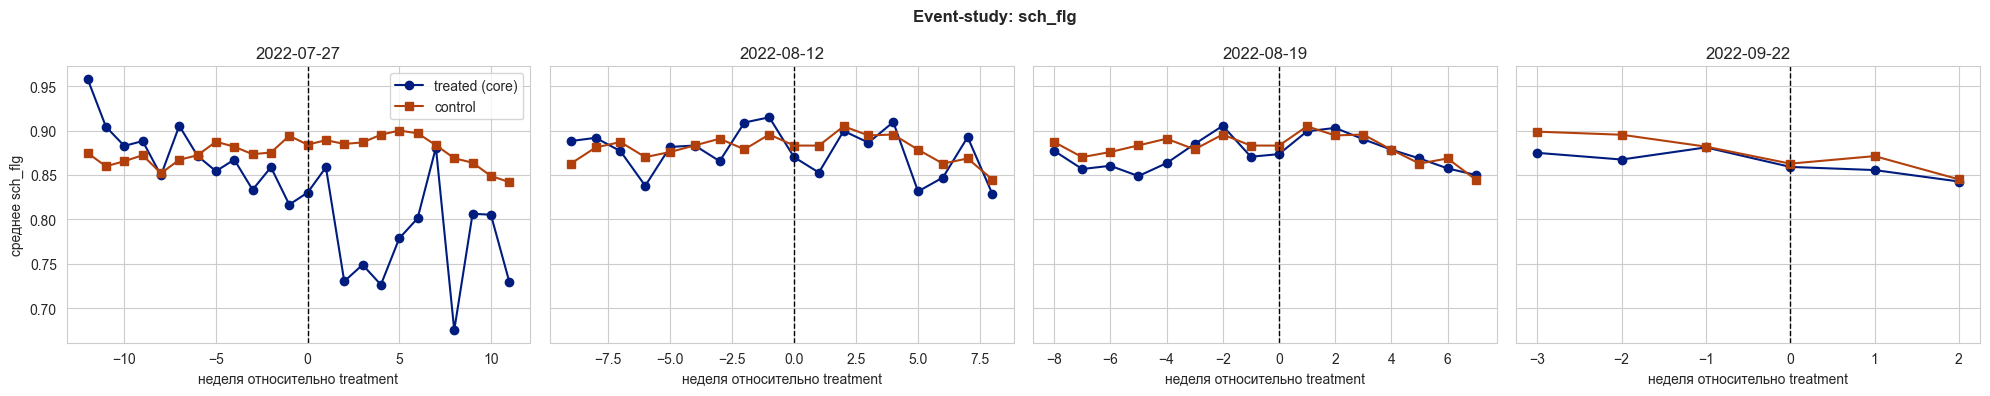

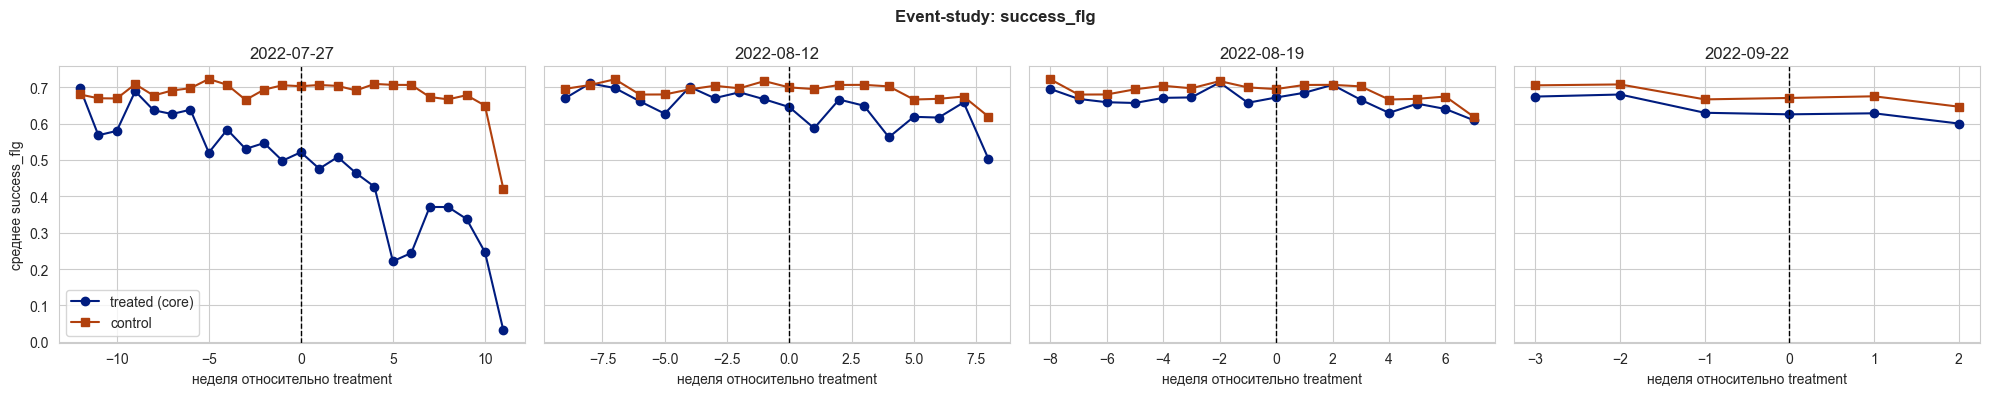

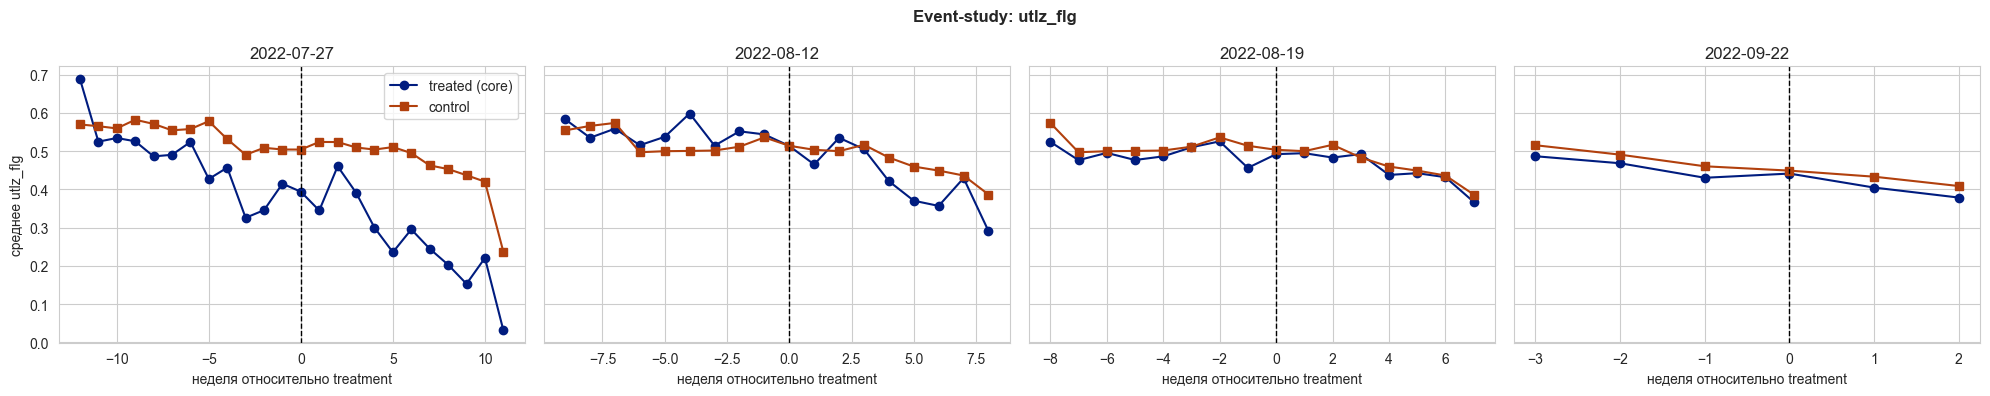

In [4]:
def event_study_frame(outcome, cohort, window):
    """
    Недельные средние метрики для treated (CORE) и control в окне [-window, +window] вокруг cohort.

    Функция принимает:
    - outcome - какую метрику анализируем, например:
        - "sch_flg" - конверсия в назначение встречи;
        - "meet_flg" - конверсия в проведение встречи;
        - "success_flg" - конверсия в успешную встречу;
        - "utlz_flg" - конверсия в утилизацию.

    - cohort - дата изменения, то есть конкретная treatment_date;
    - window - размер окна в днях вокруг этой даты.

    Техническая деталь: последняя положительная неделя на правой границе окна
    может быть неполной, например rel_week = +12 при window = 84 содержит только
    один крайний день. Поэтому после расчёта rel_week такие неполные правые недели
    отсекаются: оставляем диапазон [-window//7, window//7 - 1].
    """
    lo, hi = cohort - pd.Timedelta(days=window), cohort + pd.Timedelta(days=window)

    t = apps_t[(apps_t["treatment_date"] == cohort) & (apps_t["change_type"].isin(CORE_TYPES))].copy()
    t = t[(t["request_timestamp"] >= lo) & (t["request_timestamp"] <= hi)]
    t["rel_week"] = ((t["request_timestamp"] - cohort).dt.days // 7)

    c = apps_c[(apps_c["request_timestamp"] >= lo) & (apps_c["request_timestamp"] <= hi)].copy()
    c["rel_week"] = ((c["request_timestamp"] - cohort).dt.days // 7)

    max_full_week = window // 7
    if max_full_week >= 1:
        t = t[t["rel_week"].between(-max_full_week, max_full_week - 1)]
        c = c[c["rel_week"].between(-max_full_week, max_full_week - 1)]

    gt = t.groupby("rel_week")[outcome].mean().rename("treated")
    gc = c.groupby("rel_week")[outcome].mean().rename("control")
    return pd.concat([gt, gc], axis=1).sort_index()


def plot_event_study(outcome):
    coh = list(window_days.keys())
    fig, axes = plt.subplots(1, len(coh), figsize=(5 * len(coh), 4), sharey=True)
    if len(coh) == 1:
        axes = [axes]
    for ax, c in zip(axes, coh):
        df = event_study_frame(outcome, c, window_days[c])
        ax.plot(df.index, df["treated"], marker="o", label="treated (core)")
        ax.plot(df.index, df["control"], marker="s", label="control")
        ax.axvline(0, color="black", ls="--", lw=1)
        ax.set_title(f"{c.date()}")
        ax.set_xlabel("неделя относительно treatment")
    axes[0].set_ylabel(f"среднее {outcome}")
    axes[0].legend()
    fig.suptitle(f"Event-study: {outcome}", fontweight="bold")
    fig.tight_layout()
    plt.show()


for outcome in ["sch_flg", "success_flg", "utlz_flg"]:
    plot_event_study(outcome)

## Интерпретация событийная модель:

### sch_flg
Пред-тренды визуально близки к параллельным во всех четырёх основных когортах (07-27, 08-12, 08-19, 09-22). Возможные резкие движения на самой правой границе окна не следует интерпретировать как содержательный эффект: крайняя положительная неделя может быть неполной. В коде выше такие неполные правые недели дополнительно отсекаются.

**Вывод: визуальная диагностика не даёт явных оснований отвергать применимость DiD для `sch_flg` по основным CORE-когортам.**

### success_flg
Когорта 2022-07-27: группа воздействия снижается относительно контроль уже в пред-периоде (с $\approx 0.68$ до $\approx 0.52$ при стабильном контроле $\approx 0.70$). Если группа воздействия ухудшался ещё до изменения, то после воздействия мы уже не можем честно сказать, что дальнейшее падение вызвано именно изменением режима работы или региона гексагона. Возможно, это просто продолжение уже существующего тренда.

Когорты 2022-08-12, 2022-08-19, 2022-09-22 выглядят лучше. Для этих трёх когорт до воздействия линии воздействия и контроля идут более похоже:
- нет явного систематического расхождения до даты изменения;
- уровни близкие;
- колебания есть, но они визуально не похожи на устойчивый предтренд.

На графиках 2022-08-12, 2022-08-19, 2022-09-22 в конце окна обе линии могут снижаться. Это почти наверняка не означает, что воздействие резко испортил успешность встреч. Скорее проблема такая: заявка могла быть создана ближе к концу наблюдаемого периода, но успешная встреча могла произойти позже, уже за пределами данных. Тогда в датасете она выглядит как неуспешная, хотя на самом деле просто не успела дозреть. В таком случае мы не видим успех, потому что он случился после конца наблюдения. Поэтому `success_flg` искусственно занижается в конце периода. Это **правое цензурирование**.

### utlz_flg
Когорта 2022-07-27: группа воздействия падает значительно быстрее контроль ещё до `treatment_date`. Нарушение сильнее, чем для `success_flg`.

Когорты 08-12, 08-19, 09-22: визуально ближе к параллельности в пред-периоде. При этом цензурирование по `real_utilization_dttm` острее, чем для success, потому что лаг до утилизации обычно длиннее.

**Решение: аналогично `success_flg` - 07-27 исключается; для остальных когорт применяется порог зрелости по лагу `request_timestamp` $\rightarrow$ дата конверсии.**

### Два технических следствия, реализованные ниже
1. Вычисляется эмпирическое распределение лагов:
   - `first_success_dttm - request_timestamp` для `success_flg`;
   - `real_utilization_dttm - request_timestamp` для `utlz_flg`.

   По нему выбирается горизонт зрелости `H` (p90 лага). Затем выборка ограничивается заявками с `request_timestamp <= OBS_MAX - H`, чтобы каждая заявка имела достаточно времени для конверсии до конца наблюдаемого периода.

2. При построении панели для `success_flg` и `utlz_flg` фильтруется когорта 2022-07-27 как когорта с нарушением пред-трендов. Для `sch_flg` эта когорта сохраняется.

In [5]:
from linearmodels.panel import PanelOLS


def dynamic_did(outcome, max_week=8):
    # Для базовой динамической DiD берём только CORE-типы и только когорты,
    # у которых есть непустой pre- и post-период в window_days.
    t = apps_t[
        (apps_t["change_type"].isin(CORE_TYPES))
        & (apps_t["treatment_date"].isin(VALID_COHORTS))
    ].copy()
    t["rel_week"] = (t["days_from_treatment"] // 7).clip(-max_week, max_week)
    t["is_treated"] = 1

    c = apps_c.copy()
    c["rel_week"] = np.nan          # control: событие не наступает
    c["is_treated"] = 0

    d = pd.concat([t, c], ignore_index=True)
    d["day"] = d["request_timestamp"].dt.normalize()

    # Лиды/лаги только для treated; -1 - базовая (опущенная) категория.
    for w in range(-max_week, max_week + 1):
        if w == -1:
            continue
        d[f"w{w}"] = ((d["is_treated"] == 1) & (d["rel_week"] == w)).astype(int)

    reg_cols = [f"w{w}" for w in range(-max_week, max_week + 1) if w != -1]
    d = d.dropna(subset=[outcome]).set_index(["hex", "day"])
    mod = PanelOLS(d[outcome], d[reg_cols], entity_effects=True, time_effects=True)
    res = mod.fit(cov_type="clustered", cluster_entity=True)
    return res


res = dynamic_did("sch_flg")
print(res.summary.tables[1])
print("\nСовместная значимость ДО-периодов (w<-1) - должна быть НЕзначимой при выполнении параллельных трендов.")

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
w-8            0.0030     0.0089     0.3337     0.7386     -0.0144      0.0203
w-7           -0.0055     0.0123    -0.4499     0.6528     -0.0296      0.0186
w-6            0.0056     0.0118     0.4745     0.6352     -0.0175      0.0287
w-5           -0.0061     0.0115    -0.5280     0.5975     -0.0286      0.0164
w-4            0.0014     0.0115     0.1196     0.9048     -0.0212      0.0240
w-3           -0.0114     0.0122    -0.9393     0.3476     -0.0353      0.0124
w-2           -0.0014     0.0116    -0.1232     0.9019     -0.0241      0.0212
w0            -0.0075     0.0122    -0.6134     0.5396     -0.0315      0.0165
w1            -0.0031     0.0117    -0.2663     0.7900     -0.0260      0.0198
w2            -0.0001     0.0116    -0.0128     0.98

Строим динамическую DiD / событийная модель регрессию. Смысл: оценить, как меняется исход у гексагонов воздействия по неделям до и после воздействия, относительно базовой недели -1, с контролем на постоянные различия между гексагонами, общие дневные шоки, кластеризованные ошибки по гексагонам.

Пропускаем `w-1`, так как неделя -1 - базовая категория. Все коэффициенты будут интерпретироваться относительно недели перед воздействие. То есть модель отвечает на вопрос: насколько исход в группе воздействия в неделе w отличается от группы воздействия в неделе -1, с учётом контроль-группы, фиксированные эффекты по гексагонам и фиксированные эффекты по дням?

$$
Y_i = \sum_{\substack{k=-8 \\ k \neq -1}}^{8}
\beta_k \left(Treated_{h(i)} \cdot \mathbf{1}[e_i = k]\right)
+ \gamma_{h(i)} + \delta_{d(i)} + \varepsilon_i
$$

где: $Y_i$ - `sch_flg` заявки $i$ (ЛВМ на уровне заявок); $Treated_{h(i)} = 1$, если гексагон относится к одной из CORE-категорий (`region_only, workmode_only, region_and_workmode`), и 0 для постоянной контрольной группы; $e_i = \left\lfloor \frac{days\_from\_treatment_i}{7} \right\rfloor$, обрезанное до $[-8, 8]$ - относительная неделя события; базовая (опущенная) категория - неделя −1; $\gamma_h$ - фиксированный эффект гексагона; $\delta_d$ - фиксированный эффект календарного дня; стандартные ошибки кластеризованы по гексагону.

Иными словами, это динамическая (событийная модель) спецификация: каждый $\beta_k$ - разность вероятности `sch_flg=1` между воздействия и контроля на относительной неделе k по сравнению с неделей −1, очищенная от эффектов гексагона и дня. Так как зависимая переменная бинарная, коэффициент измеряется в долях вероятности; для перевода в процентные пункты его нужно умножить на 100.

Была оценена спецификация событийной модели с фиксированными эффектами гексагона и календарного дня. В качестве базового периода использована неделя, непосредственно предшествующая изменению конфигурации гексагона. Коэффициенты при недельных индикаторах показывают изменение вероятности назначения встречи относительно базовой недели. Полученные оценки не выявляют статистически значимого влияния изменения конфигурации на вероятность назначения встречи: все доверительные интервалы включают ноль, а p-value превышают стандартные уровни значимости. Кроме того, коэффициенты до воздействия не являются статистически значимыми, что не дает явных свидетельств нарушения предпосылки параллельных трендов.

Для частичной проверки предпосылки параллельных трендов используется спецификация событийной модели, в которой для гексагонов воздействия вводятся индикаторы относительных периодов до и после изменения. Базовым периодом является неделя непосредственно перед изменением, $w=-1$, которая исключается из модели. Коэффициенты при периодах $w<0$ позволяют проверить наличие систематических различий в динамике групп воздействия и контроля до изменения. Если до изменения эти коэффициенты статистически неотличимы от нуля, это является аргументом в пользу предпосылки параллельных трендов. Коэффициенты при $w\geq 0$ описывают динамику показателя после изменения конфигурации.

### Интерпретация результатов для `sch_flg`

В качестве зависимой переменной была использована метрика `sch_flg`, отражающая факт назначения встречи. Была оценена динамическая спецификация событийной модели с фиксированными эффектами гексагона и календарного дня. Базовой категорией выступает неделя `-1`, то есть неделя непосредственно перед изменением конфигурации гексагона.

#### До-период: проверка предпосылки параллельных трендов

Коэффициенты при переменных `w-8`–`w-2` отражают различия между группами воздействия и контроля в период до изменения конфигурации. Эти коэффициенты используются для проверки того, существовали ли заметные различия в динамике метрики ещё до наступления воздействие.

Полученные оценки малы по модулю: значения коэффициентов находятся примерно в диапазоне от `-0.012` до `0.001`. Все коэффициенты до-периода статистически незначимы: p-value находятся выше стандартных уровней значимости. Это означает, что по отдельным недельным коэффициентам не обнаружено статистически значимых отклонений от предпосылки параллельных трендов для метрики `sch_flg`.

При этом данный вывод следует формулировать осторожно: отсутствие значимости отдельных коэффициентов не доказывает выполнение параллельных трендов, а лишь не даёт оснований отвергнуть эту предпосылку. Для более строгой проверки необходимо дополнительно провести совместный тест значимости всех коэффициентов до-периода.

#### Пост-период: оценка динамики эффекта

Коэффициенты `w0`–`w8` показывают изменение вероятности назначения встречи после изменения конфигурации гексагона относительно базовой недели `-1`.

Все коэффициенты пост-периода статистически незначимы. Точечные оценки колеблются около нуля: примерно от `-0.015` до `0.010`. Так как зависимая переменная `sch_flg` является бинарной, коэффициенты измеряются в долях вероятности. После умножения на 100 их можно читать как процентные пункты. Например, коэффициент `-0.015` соответствует снижению вероятности назначения встречи примерно на 1.5 процентного пункта.

Однако доверительные интервалы для всех пост-периодов включают ноль, а p-value превышают стандартные уровни значимости. Следовательно, в данной спецификации не выявлено статистически значимого влияния изменения конфигурации гексагона на вероятность назначения встречи.

#### Итоговый вывод

Результаты событийной модели для `sch_flg` указывают на отсутствие статистически значимого эффекта изменения конфигурации гексагона на вероятность назначения встречи. До наступления воздействие не наблюдается значимых отличий по недельным коэффициентам, что не противоречит предпосылке параллельных трендов. После воздействие коэффициенты также остаются статистически незначимыми и близкими к нулю.

Таким образом, для метрики `sch_flg` нулевая гипотеза об отсутствии статистически различимого эффекта не отвергается.

## 2. DiD по отдельным типам воздействия

В разделе 1 группа воздействия объединяла все CORE-типы (`region_only`, `workmode_only`, `region_and_workmode`). Здесь та же спецификация событийной модели оценивается **отдельно для каждого типа воздействия**, включая открытие и закрытие зоны:

- `region_only` — изменился только регион;
- `workmode_only` — изменился только режим работы;
- `region_and_workmode` — изменились и регион, и режим;
- `closed` — гексагон исключён из зоны доставки;
- `opened` — гексагон добавлен в зону доставки.

Для каждого типа группа воздействия — это только single-change гексагоны данного типа, а контроль — те же постоянной контрольной группы гексагоны. Спецификация идентична разделу 1:

$$
Y_i = \sum_{\substack{k=-8 \\ k \neq -1}}^{8}
\beta_k \left(Treated_{h(i)} \cdot \mathbb{1}[e_i = k]\right)
+ \gamma_{h(i)} + \delta_{d(i)} + \varepsilon_i
$$

базовая неделя $k=-1$, фиксированные эффекты гексагона $\gamma_h$ и календарного дня $\delta_d$, стандартные ошибки кластеризованы по гексагону. Коэффициенты $\beta_{k<-1}$ проверяют параллельные тренды (совместный Wald-тест), $\beta_{k\geq 0}$ описывают динамику эффекта после воздействия.

**Важная оговорка про `opened` / `closed`.** Результаты для `opened` и `closed` используются только как описательная диагностика. Они не интерпретируются как чистый причинный DiD-эффект, потому что наличие заявок до или после воздействия структурно связано с самим типом изменения зоны. Для `opened` гексагон до воздействия неактивен, поэтому в пред-периоде заявок почти нет. Для `closed` ситуация зеркальная: после воздействия заявок мало или нет. Поэтому полноценная проверка параллельных трендов и стандартная причинная интерпретация для этих двух типов существенно ослаблены.

In [6]:
# Типы воздействия для отдельных DiD-оценок и метрики
TYPE_LABELS = {
    "region_only": "регион",
    "workmode_only": "режим",
    "region_and_workmode": "регион+режим",
    "closed": "закрытие",
    "opened": "открытие",
}
TYPES = list(TYPE_LABELS)
OUTCOMES = ["sch_flg", "success_flg", "utlz_flg"]

# Для conversion-метрик когорта 2022-07-27 исключается из причинной оценки:
# визуальная диагностика показывает нарушение пред-трендов для success_flg/utlz_flg.
EXCLUDED_COHORT_FOR_CONVERSION = pd.Timestamp("2022-07-27")
CONVERSION_OUTCOMES = {"success_flg", "utlz_flg"}

# Колонка с датой фактического наступления события для оценки правого цензурирования.
OUTCOME_EVENT_DTTM = {
    "success_flg": "first_success_dttm",
    "utlz_flg": "real_utilization_dttm",
}


class EmptyWaldResult:
    """Заглушка для случаев, когда нет доступных pre-period коэффициентов для Wald-теста."""
    pval = np.nan
    stat = np.nan


def maturity_horizon_days(outcome, quantile=0.90):
    """
    Эмпирический горизонт зрелости H для conversion-метрик.

    H = quantile лагов между request_timestamp и датой фактической конверсии.
    После этого заявки с request_timestamp > OBS_MAX - H исключаются, чтобы не
    считать недозревшие заявки как отрицательный исход только из-за конца данных.
    Для sch_flg горизонт зрелости не нужен, возвращается 0.
    """
    event_col = OUTCOME_EVENT_DTTM.get(outcome)
    if event_col is None:
        return 0
    if event_col not in apps_t.columns or event_col not in apps_c.columns:
        return 0

    lag_df = pd.concat(
        [apps_t[["request_timestamp", event_col]], apps_c[["request_timestamp", event_col]]],
        ignore_index=True,
    ).dropna(subset=["request_timestamp", event_col])

    if lag_df.empty:
        return 0

    lags = (lag_df[event_col] - lag_df["request_timestamp"]).dt.total_seconds() / 86400
    lags = lags[(lags >= 0) & np.isfinite(lags)]
    if lags.empty:
        return 0

    return int(np.ceil(lags.quantile(quantile)))


def valid_treated_cohorts(outcome):
    """
    Когорты, допустимые для оценки конкретной метрики.
    Для sch_flg сохраняются все когорты с pre/post-периодом.
    Для success_flg и utlz_flg дополнительно исключается 2022-07-27.
    """
    cohorts = set(VALID_COHORTS)
    if outcome in CONVERSION_OUTCOMES:
        cohorts = cohorts - {EXCLUDED_COHORT_FOR_CONVERSION}
    return cohorts


def filter_mature_requests(df, outcome, quantile=0.90):
    """
    Ограничивает выборку по зрелости заявок для conversion-метрик.
    Возвращает отфильтрованный DataFrame и использованный горизонт H.
    """
    h = maturity_horizon_days(outcome, quantile=quantile)
    if h <= 0:
        return df.copy(), h

    cutoff = OBS_MAX - pd.Timedelta(days=h)
    return df[df["request_timestamp"] <= cutoff].copy(), h


def make_treated_sample(outcome, change_type):
    """
    Единая treated-выборка для конкретной пары outcome × change_type.
    Здесь применяются оба ключевых фильтра:
    1) только когорты с pre/post-периодом;
    2) для success_flg/utlz_flg исключается 2022-07-27;
    3) для success_flg/utlz_flg применяется фильтр зрелости заявок.
    """
    t = apps_t[
        (apps_t["change_type"] == change_type)
        & (apps_t["treatment_date"].isin(valid_treated_cohorts(outcome)))
    ].copy()
    t, _ = filter_mature_requests(t, outcome)
    return t


def make_control_sample(outcome):
    """
    Control-выборка. Для conversion-метрик применяется тот же фильтр зрелости,
    чтобы treated и control сравнивались на одинаково наблюдаемом горизонте.
    """
    c, _ = filter_mature_requests(apps_c.copy(), outcome)
    return c


def _full_rank_event_columns(d, reg_cols):
    """
    Убирает event-week dummy-колонки, которые нельзя оценить:
    - колонка полностью нулевая после фильтра outcome;
    - колонка линейно зависима от уже оставленных колонок.

    Это лучше, чем ставить check_rank=False: мы не оставляем в модели
    неидентифицируемые коэффициенты.
    """
    active = []
    for col in reg_cols:
        if col not in d.columns:
            continue
        # У dummy должна быть хотя бы одна единица и хотя бы один ноль.
        if d[col].sum() == 0 or d[col].nunique(dropna=False) < 2:
            continue
        active.append(col)

    kept = []
    for col in active:
        candidate = kept + [col]
        x = d[candidate].to_numpy(dtype=float)
        if np.linalg.matrix_rank(x) > len(kept):
            kept.append(col)
    return kept


def did_event_study(outcome, change_type, max_week=8):
    """
    Event-study DiD для одного типа воздействия change_type против never-treated.

    treated - только single-change гексагоны типа change_type; control - apps_c.
    Спецификация и FE идентичны dynamic_did из раздела 1, но регрессоры названы
    без минусов (pre{k}/post{k}), чтобы их принимал Wald-тест по формуле.

    Важно: после фильтрации по когортам и зрелости часть event-week dummy может
    стать полностью пустой. Такие колонки автоматически исключаются, иначе
    PanelOLS падает с ошибкой `exog does not have full column rank`.

    Returns
    -------
    res : результат PanelOLS
    coefs : DataFrame по относительной неделе (coef, ci_low, ci_high, pval)
            для неоценимых недель стоит NaN.
    wald : совместный Wald-тест пред-трендов; если pre-коэффициентов нет, pval = NaN.
    """
    name = lambda w: f"pre{-w}" if w < 0 else f"post{w}"
    weeks = [w for w in range(-max_week, max_week + 1) if w != -1]   # -1 - база (опущена)

    t = make_treated_sample(outcome, change_type)
    if t.empty:
        raise ValueError(f"Пустая treated-выборка для outcome={outcome}, change_type={change_type}")

    t["rel_week"] = (t["days_from_treatment"] // 7).clip(-max_week, max_week)
    t["is_treated"] = 1

    c = make_control_sample(outcome)
    c["rel_week"] = np.nan          # control: событие не наступает
    c["is_treated"] = 0

    d = pd.concat([t, c], ignore_index=True)
    d["day"] = d["request_timestamp"].dt.normalize()

    for w in weeks:
        d[name(w)] = ((d["is_treated"] == 1) & (d["rel_week"] == w)).astype(int)

    all_reg_cols = [name(w) for w in weeks]
    d = d.dropna(subset=[outcome]).set_index(["hex", "day"])
    reg_cols = _full_rank_event_columns(d, all_reg_cols)

    if not reg_cols:
        raise ValueError(
            f"Нет оцениваемых event-week dummy после фильтров для outcome={outcome}, "
            f"change_type={change_type}"
        )

    res = (
        PanelOLS(
            d[outcome],
            d[reg_cols],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
        )
        .fit(cov_type="clustered", cluster_entity=True, low_memory=True)
    )

    ci = res.conf_int()
    rows = []
    for w in weeks:
        col = name(w)
        if col in res.params.index:
            rows.append({
                "rel_week": w,
                "coef": res.params[col],
                "ci_low": ci.loc[col, "lower"],
                "ci_high": ci.loc[col, "upper"],
                "pval": res.pvalues[col],
                "estimated": True,
            })
        else:
            rows.append({
                "rel_week": w,
                "coef": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "pval": np.nan,
                "estimated": False,
            })

    coefs = pd.DataFrame(rows).set_index("rel_week").sort_index()

    pre_cols = [name(w) for w in weeks if w < -1 and name(w) in res.params.index]
    if pre_cols:
        wald = res.wald_test(formula=", ".join(f"{col} = 0" for col in pre_cols))
    else:
        wald = EmptyWaldResult()

    return res, coefs, wald


In [7]:
# Оценка event-study DiD отдельно для каждого типа воздействия и каждой метрики
# (5 типов × 3 метрики = 15 регрессий; PanelOLS с двусторонними FE — может занять время)
results = {}
summary_rows = []

for outcome in OUTCOMES:
    h = maturity_horizon_days(outcome)
    for ctype in TYPES:
        treated_used = make_treated_sample(outcome, ctype)
        try:
            res, coefs, wald = did_event_study(outcome, ctype)
            results[(outcome, ctype)] = {"res": res, "coefs": coefs, "wald": wald, "H_days": h, "status": "ok"}
            post = coefs.loc[coefs.index >= 0, "coef"].dropna()
            summary_rows.append({
                "outcome": outcome,
                "тип": TYPE_LABELS[ctype],
                "treated-гексов": treated_used["hex"].nunique(),
                "H зрелости, дней": h,
                "pretrend_pval": wald.pval,
                "сред. пост-эффект, п.п.": 100 * post.mean() if not post.empty else np.nan,
                "статус": "ok",
            })
        except Exception as e:
            # Для opened/closed и сильно отфильтрованных conversion-метрик часть регрессий
            # может быть неидентифицируема. Это фиксируется в таблице, а не останавливает весь прогон.
            results[(outcome, ctype)] = {"error": str(e), "H_days": h, "status": "error"}
            summary_rows.append({
                "outcome": outcome,
                "тип": TYPE_LABELS[ctype],
                "treated-гексов": treated_used["hex"].nunique(),
                "H зрелости, дней": h,
                "pretrend_pval": np.nan,
                "сред. пост-эффект, п.п.": np.nan,
                "статус": f"skip: {str(e)[:90]}",
            })

summary = pd.DataFrame(summary_rows)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(summary.to_string(index=False))


    outcome          тип  treated-гексов  H зрелости, дней  pretrend_pval  сред. пост-эффект, п.п. статус
    sch_flg       регион             826                 0         0.0127                  -2.8000     ok
    sch_flg        режим            2649                 0         0.5351                   0.3059     ok
    sch_flg регион+режим            3831                 0         0.8310                   0.8381     ok
    sch_flg     закрытие             876                 0         0.0278                 -17.5796     ok
    sch_flg     открытие             868                 0         0.5774                   5.1128     ok
success_flg       регион             798                20         0.0712                  -5.1422     ok
success_flg        режим            2396                20         0.7807                  -3.4357     ok
success_flg регион+режим            3673                20         0.2870                   2.0774     ok
success_flg     закрытие             839      

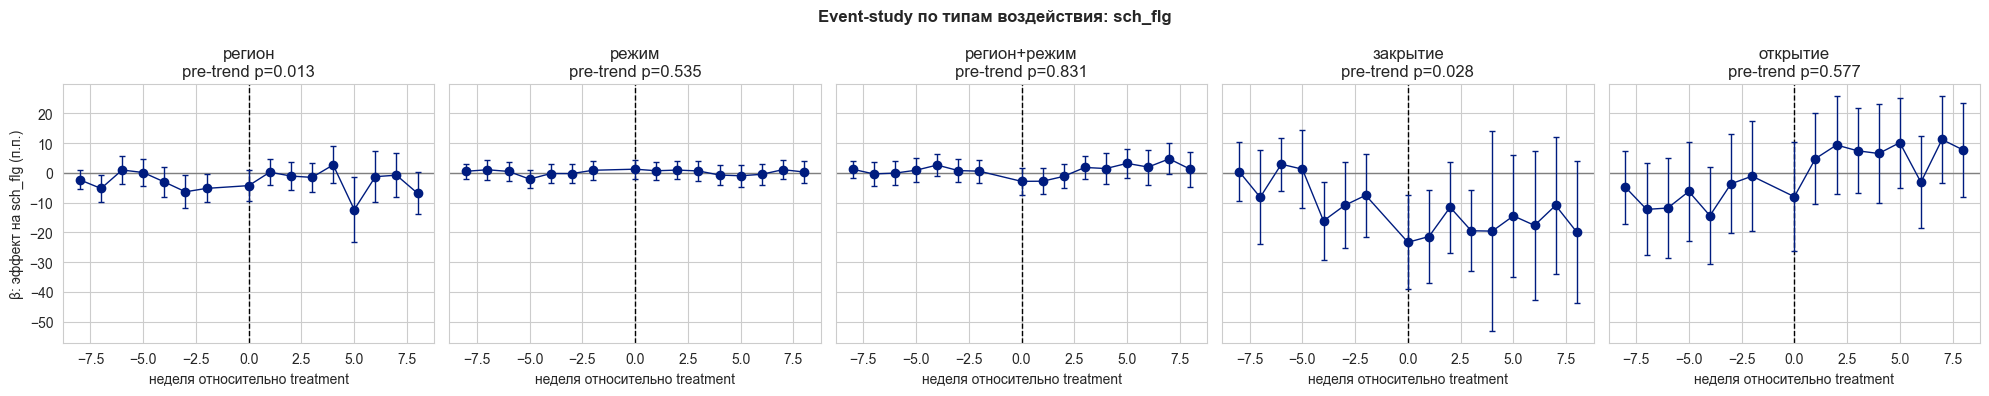

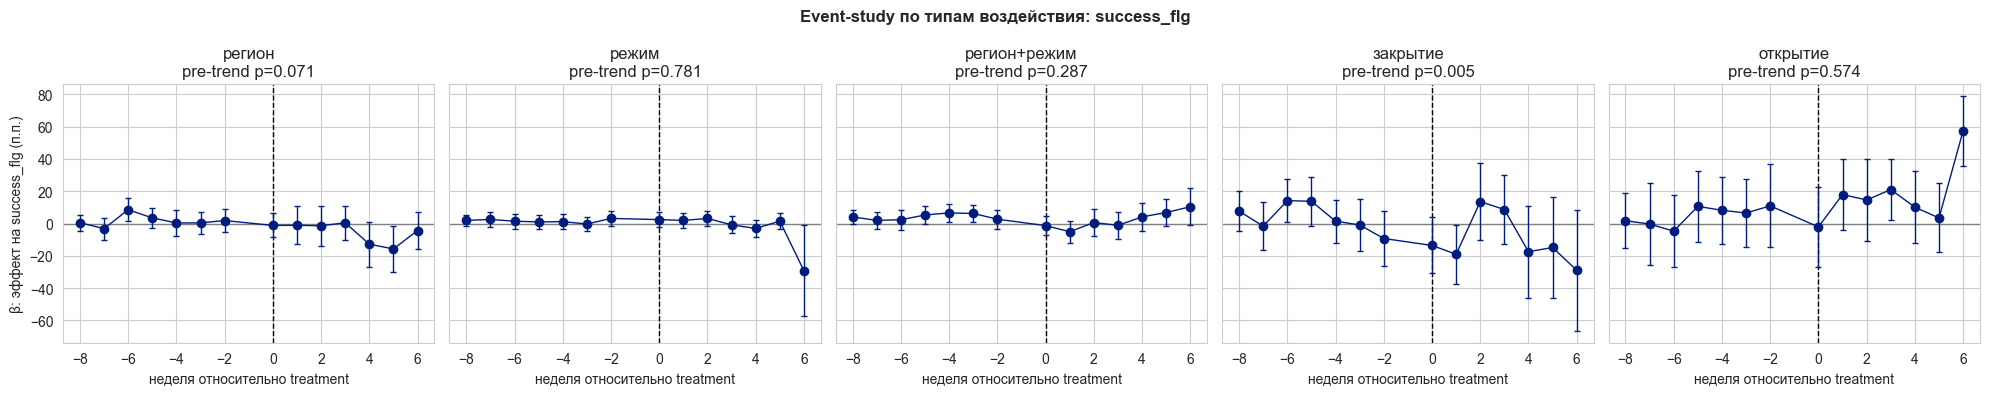

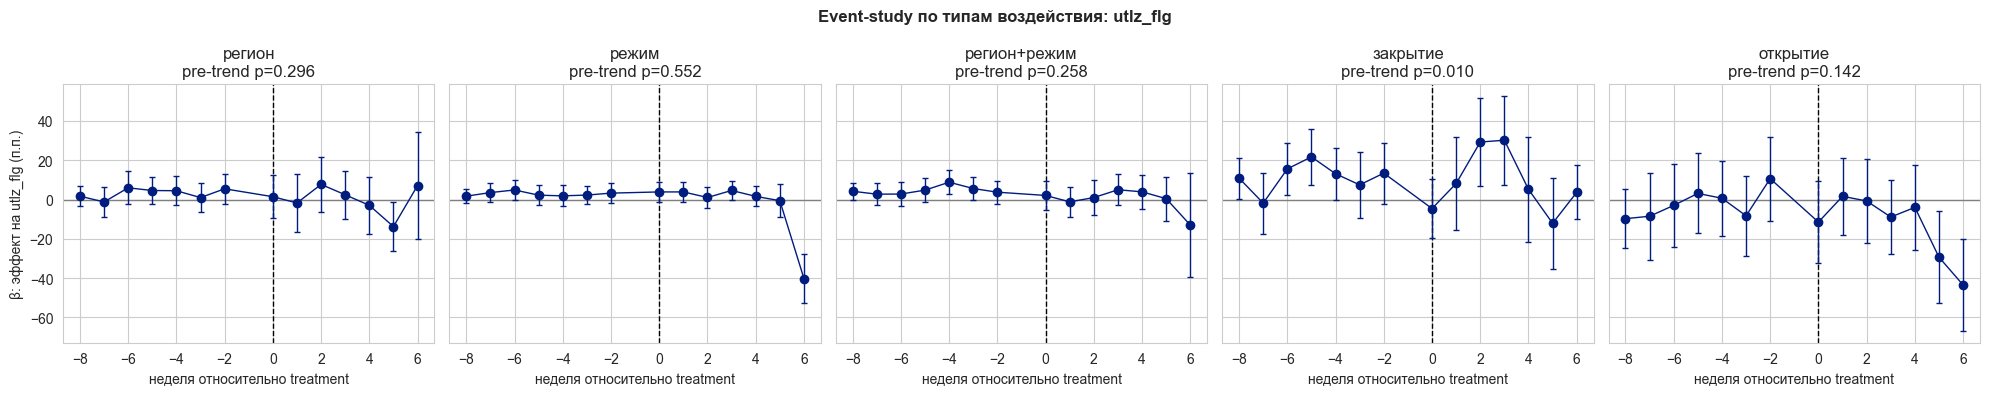

In [8]:
def plot_did_by_type(outcome):
    """Event-study коэффициенты с 95% CI по каждому типу воздействия для одной метрики."""
    fig, axes = plt.subplots(1, len(TYPES), figsize=(4 * len(TYPES), 4), sharey=True)
    for ax, ctype in zip(axes, TYPES):
        item = results.get((outcome, ctype), {})
        ax.axhline(0, color="grey", lw=1)
        ax.axvline(0, color="black", ls="--", lw=1)          # момент treatment
        ax.set_title(TYPE_LABELS[ctype])
        ax.set_xlabel("неделя относительно treatment")

        if "coefs" not in item:
            ax.text(0.5, 0.5, "не оценено", ha="center", va="center", transform=ax.transAxes)
            continue

        coefs = item["coefs"].dropna(subset=["coef", "ci_low", "ci_high"])
        if coefs.empty:
            ax.text(0.5, 0.5, "нет оцениваемых\nкоэффициентов", ha="center", va="center", transform=ax.transAxes)
            continue

        wald = item["wald"]
        pval_text = "NA" if pd.isna(wald.pval) else f"{wald.pval:.3f}"

        coef_pp = 100 * coefs["coef"]
        ci_low_pp = 100 * coefs["ci_low"]
        ci_high_pp = 100 * coefs["ci_high"]

        ax.errorbar(
            coefs.index,
            coef_pp,
            yerr=[coef_pp - ci_low_pp, ci_high_pp - coef_pp],
            marker="o",
            capsize=2,
            lw=1,
        )
        ax.set_title(f"{TYPE_LABELS[ctype]}\npre-trend p={pval_text}")

    axes[0].set_ylabel(f"β: эффект на {outcome} (п.п.)")
    fig.suptitle(f"Event-study по типам воздействия: {outcome}", fontweight="bold")
    fig.tight_layout()
    plt.show()


for outcome in OUTCOMES:
    plot_did_by_type(outcome)


### Как читать таблицу и графики

- **`pretrend_pval`** — p-value совместного Wald-теста коэффициентов до воздействия ($\beta_{-8},\dots,\beta_{-2}=0$). Большое значение (ориентир: $>0.1$) означает, что в данных не обнаружено статистически значимого пред-тренда. Это не доказывает параллельные тренды, но не противоречит этой предпосылке. Причинная интерпретация возможна только вместе с остальными идентификационными предположениями и корректной спецификацией выборки. Маленькое значение указывает на пред-тренд: оценку эффекта для такого типа нельзя считать чистым эффектом воздействия.
- **`H зрелости, дней`** — эмпирический p90 лага от заявки до фактической конверсии. Для `sch_flg` равен 0, потому что отдельная дата дозревания не нужна. Для `success_flg` и `utlz_flg` этот горизонт используется для отсечения заявок около конца наблюдаемого периода.
- **`сред. пост-эффект, п.п.`** — среднее коэффициентов $\beta_{k\geq 0}$, уже умноженное на 100 и выраженное в процентных пунктах. Это грубый ориентир направления и масштаба эффекта; его надо смотреть вместе с доверительными интервалами на графике.
- **Графики** — точечные оценки $\beta_k$ с 95% доверительными интервалами по относительным неделям; пунктир в нуле — момент воздействия, база — неделя $-1$. На графиках коэффициенты также переведены в процентные пункты. Если до нуля коэффициенты лежат около нуля, а после нуля систематически смещаются и их CI не накрывают ноль — это признак эффекта данного типа воздействия.

При интерпретации `success_flg` и `utlz_flg` учитывается **правое цензурирование**: заявки, созданные ближе к концу периода наблюдения, могли конвертироваться уже после окончания доступных данных. Для этого введён фильтр зрелости по `H`. Для `opened`/`closed` результаты всё равно остаются описательными, а не полноценными причинный DiD-оценками, поскольку сам факт наличия заявок по сторонам от воздействие структурно связан с открытием или закрытием зоны.

In [9]:
# Предоценочная динамика по когортам
# PROJECT_ROOT задаётся ниже при NameError, если ячейка запускается отдельно.
# Графики строятся из уже созданных выше объектов apps_t, apps_c, window_days и CORE_TYPES.

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    PROJECT_ROOT
except NameError:
    cwd = Path.cwd().resolve()
    # Если ноутбук лежит в папке notebooks, корень проекта обычно на уровень выше.
    PROJECT_ROOT = cwd.parent if (cwd.parent / "data" / "raw").exists() else cwd

FIG_DIR = PROJECT_ROOT / "figures" / "empirical"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(
    context="paper",
    style="whitegrid",
    font="DejaVu Sans",
    palette="Set2",
    rc={
        "figure.dpi": 130,
        "savefig.dpi": 300,
        "axes.titlesize": 12.5,
        "axes.labelsize": 10.5,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "legend.fontsize": 9,
        "legend.title_fontsize": 9.5,
    },
)

OUTCOME_LABELS = {
    "sch_flg": "Доля назначенных встреч",
    "success_flg": "Доля успешных встреч",
    "utlz_flg": "Доля утилизаций",
}


def pretrend_frame(outcome, cohort, window):
    """Недельные средние treated/control в симметричном окне вокруг когорты."""
    return event_study_frame(outcome, pd.Timestamp(cohort), window)


@with_plot_style
def plot_pretrends_by_cohort(outcome, filename):
    cohorts_to_plot = list(window_days.keys())
    n = len(cohorts_to_plot)
    if n == 0:
        raise ValueError("window_days пустой: нет когорт с непустым pre- и post-периодом.")

    ncols = 2 if n > 1 else 1
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.4 * ncols, 3.35 * nrows),
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()
    export_frames = []

    for ax, cohort in zip(axes, cohorts_to_plot):
        df = pretrend_frame(outcome, cohort, window_days[cohort])
        export_part = df.rename_axis("event_week").reset_index()
        export_part["outcome"] = outcome
        export_part["cohort"] = pd.Timestamp(cohort).strftime("%Y-%m-%d")
        export_frames.append(export_part)

        ax.plot(
            df.index,
            df["treated"],
            marker="o",
            linewidth=2,
            markersize=4.5,
            label="Treated CORE",
            color=PALETTE["treated"],
        )
        ax.plot(
            df.index,
            df["control"],
            marker="s",
            linewidth=2,
            markersize=4.5,
            label="Control",
            color=PALETTE["control"],
            linestyle="--",
            markerfacecolor="white",
        )

        ax.axvline(0, color="#111827", linestyle="--", linewidth=1)
        ax.set_title(pd.Timestamp(cohort).strftime("%Y-%m-%d"))
        ax.set_xlabel("Неделя относительно изменения")
        ax.grid(axis="y", alpha=0.35)
        ax.grid(axis="x", alpha=0.15)

    for extra_ax in axes[n:]:
        extra_ax.set_visible(False)

    for ax in axes[::ncols]:
        ax.set_ylabel(OUTCOME_LABELS.get(outcome, outcome))

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Группа",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=True,
    )

    fig.suptitle(
        f"Предоценочная динамика: {OUTCOME_LABELS.get(outcome, outcome)}",
        y=1.06,
        fontsize=14,
        fontweight="bold",
    )

    sns.despine(fig=fig)
    fig.tight_layout()

    export_dir = PROJECT_ROOT / "outputs" / "empirical"
    export_dir.mkdir(parents=True, exist_ok=True)
    pd.concat(export_frames, ignore_index=True).to_csv(
        export_dir / f"_pretrends_{outcome}.csv", index=False
    )
    pdf_path = FIG_DIR / f"{filename}.pdf"
    save_figure(fig, pdf_path, preview_png=True, preview_dpi=240)
    print(f"Сохранено: {pdf_path}")


plot_pretrends_by_cohort("sch_flg", "pretrends_sch_by_cohort")
plot_pretrends_by_cohort("success_flg", "pretrends_success_by_cohort")
plot_pretrends_by_cohort("utlz_flg", "pretrends_utlz_by_cohort")

Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


## Вывод

Раздельная оценка событийная модель DiD по типам изменения показывает, что эффект изменений логистической конфигурации неоднороден и зависит от типа воздействия. Объединение всех гексагонов воздействия в одну группу может скрывать эту гетерогенность, поэтому дальнейшая интерпретация должна строиться отдельно для `region_only`, `workmode_only` и `region_and_workmode`.

Для метрики `sch_flg`, то есть вероятности назначения встречи, наиболее надёжно интерпретируются типы `workmode_only` и `region_and_workmode`: для них Wald-тест не выявляет статистически значимых пред-трендов (`p = 0.535` и `p = 0.831`). При этом средний постэффект мал: около `+0.31` п.п. для изменения режима и `+0.84` п.п. для одновременного изменения региона и режима. Это означает, что убедительного устойчивого влияния этих изменений на вероятность назначения встречи не обнаружено. Для `region_only` наблюдается значимый пред-тренд (`p = 0.013`), поэтому средний постэффект `-2.8` п.п. нельзя интерпретировать как чистый причинный эффект.

Для метрики `success_flg`, то есть вероятности успешной встречи, результаты осторожно указывают на различия между типами воздействия. Для `workmode_only` пред-тренд не выявлен (`p = 0.781`), но средний постэффект составляет около `-3.44` п.п. и на графике не выглядит как устойчивое снижение на всём post-периоде: большая часть динамики близка к нулю, а отрицательное значение заметно усиливается ближе к концу окна. Поэтому этот результат следует трактовать осторожно. Для `region_and_workmode` пред-тренд также не выявлен (`p = 0.287`), а средний постэффект положительный, около `+2.08` п.п. Это наиболее содержательный кандидат на положительный эффект среди CORE-типов для `success_flg`, хотя его всё равно нужно сверять с доверительными интервалами. Для `region_only` p-value пред-тренда пограничный (`p = 0.071`), поэтому средний эффект `-5.14` п.п. нельзя считать надёжной причинной оценкой без оговорок.

Для метрики `utlz_flg`, то есть вероятности утилизации продукта, у всех трёх CORE-типов нет статистически значимых пред-трендов: `region_only` (`p = 0.296`), `workmode_only` (`p = 0.552`), `region_and_workmode` (`p = 0.258`). Однако средние постэффекты не дают сильного свидетельства о содержательном улучшении: для `region_only` эффект практически нулевой (`+0.04` п.п.), для `region_and_workmode` также близок к нулю (`-0.24` п.п.), а для `workmode_only` составляет около `-3.67` п.п., но визуально заметная отрицательная динамика концентрируется ближе к концу окна. Поэтому по `utlz_flg` нельзя уверенно говорить о стабильном положительном или отрицательном эффекте изменений.

Типы `opened` и `closed` не следует использовать для причинной интерпретации. Для `closed` есть значимые пред-тренды по всем трём метрикам или почти по всем ключевым проверкам, а сам факт закрытия зоны структурно меняет наличие заявок после воздействия. Для `opened` средние эффекты могут быть большими, например `+17.52` п.п. по `success_flg`, но это скорее отражает структурное появление активной зоны и изменение состава заявок, а не чистый DiD-эффект.

Итогово, наиболее аккуратный вывод такой: изменения режима работы и одновременные изменения региона и режима не ухудшают вероятность назначения встречи; для успешной встречи возможен умеренный положительный эффект у типа `region_and_workmode`, но он требует осторожной интерпретации; для утилизации устойчивого эффекта не обнаружено. Результаты по `region_only` слабее из-за проблем с пред-трендами, а `opened` и `closed` следует рассматривать только как описательные кейсы, а не как полноценные причинный DiD-оценки.
